In [1]:
# %% [markdown]
# # lab5: 고전 데이터를 양자 상태로 — 데이터 인코딩
# ### 양자 머신러닝 실습 (PennyLane · Colab)
#
# 양자 머신러닝의 첫 관문: **고전 데이터를 큐빗에 실어 넣기(encoding)**.
# 회로는 숫자를 직접 못 받는다. 데이터를 '회전각'으로 바꿔 양자 상태로 만들어야
# 이후의 양자 커널·변분회로가 그 위에서 동작한다.
#
# **학습 목표**
# 1. 왜 인코딩이 필요한가 — 데이터가 곧 양자 상태가 된다.
# 2. 각도 인코딩(angle encoding): 특징값 d 를 RY(arccos d) 로 실으면 <Z> = d.
# 3. 회전의 주기성 문제와 Min-Max 스케일링 (실제 데이터 전처리).
# 4. 데이터 벡터를 여러 큐빗에 인코딩하고 다시 읽어낸다.
# 5. 서로 다른 데이터 → 서로 다른 양자 상태(= 특징), 그리고 특징 사상으로의 다리.
#
# (그림 라벨은 영어, 코드 주석/출력은 한글)

# %%
# 설치 — Colab에서 최초 1회만: 아래 줄의 주석을 해제해 실행

!pip install -q pennylane

import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SEED = 1234


In [2]:


# %%
# ===========================================================
#  5-1: 특징 하나 인코딩 — RY(arccos d) 로 <Z> = d
# ===========================================================
print("=" * 60)
print("lab5-1: 데이터 값 하나를 양자 상태로")
print("=" * 60)

dev1 = qml.device("default.qubit", wires=1)


@qml.qnode(dev1)
def encode_one(d):
    qml.RY(np.arccos(d), wires=0)     # 각도 = arccos(d)  (d 는 [-1,1])
    return qml.expval(qml.PauliZ(0))  # <Z> = cos(arccos d) = d  (되읽기)


for d in [0.0, 0.3, 0.5, 0.9]:
    z = float(encode_one(d))
    print(f"  데이터 d={d:+.2f}  ->  <Z>={z:+.3f}  (P(0)=(1+d)/2={ (1+d)/2:.3f})")
print("  => 데이터가 각도가 되고, 기댓값으로 그대로 되읽힌다 (가역 인코딩).")


lab5-1: 데이터 값 하나를 양자 상태로
  데이터 d=+0.00  ->  <Z>=+0.000  (P(0)=(1+d)/2=0.500)
  데이터 d=+0.30  ->  <Z>=+0.300  (P(0)=(1+d)/2=0.650)
  데이터 d=+0.50  ->  <Z>=+0.500  (P(0)=(1+d)/2=0.750)
  데이터 d=+0.90  ->  <Z>=+0.900  (P(0)=(1+d)/2=0.950)
  => 데이터가 각도가 되고, 기댓값으로 그대로 되읽힌다 (가역 인코딩).


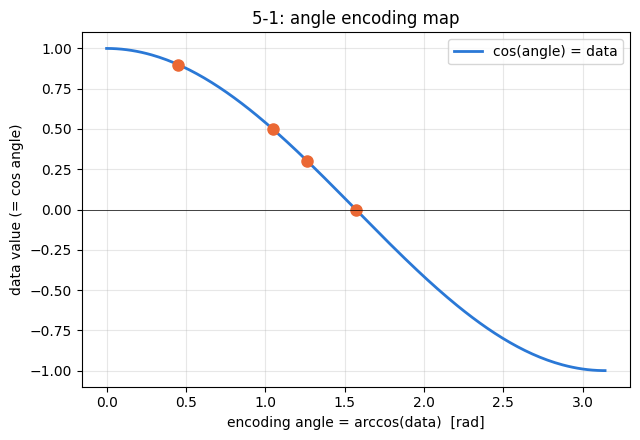

In [3]:

xs = std_np.linspace(0, np.pi, 200)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(xs, std_np.cos(xs), "-", color="#2a78d6", lw=2, label="cos(angle) = data")
for d in [0.0, 0.3, 0.5, 0.9]:
    ax.plot(np.arccos(d), d, "o", color="#eb6834", ms=8)
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("encoding angle = arccos(data)  [rad]")
ax.set_ylabel("data value (= cos angle)")
ax.set_title("5-1: angle encoding map")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [6]:

# %%
# ===========================================================
#  5-2: 회전의 주기성 문제와 Min-Max 스케일링
# ===========================================================
print("\n" + "=" * 60)
print("lab5-2: 주기성 문제와 스케일링 (실제 데이터 전처리)")
print("=" * 60)

# 실제 데이터는 범위가 제각각이다. 정수 데이터 1~100 을 RY 에 '그냥' 넣으면?
x_int = std_np.arange(1, 101)


@qml.qnode(dev1)
def encode_raw(x):
    qml.RY(x, wires=0)               # 스케일링 없이 원시 값
    return qml.expval(qml.PauliZ(0))


SCALE_MAX = np.pi                    # 목표 범위 [0, pi] (pi/2, 2pi 로 바꿔 관찰)


def min_max(x, lo=1, hi=100, top=SCALE_MAX):
    return (x - lo) / (hi - lo) * top


raw = std_np.array([float(encode_raw(float(x))) for x in x_int])
scaled = std_np.array([float(encode_raw(min_max(float(x)))) for x in x_int])

print(f"  스케일링 없음: x=1 -> {raw[0]:+.3f},  x=50 -> {raw[49]:+.3f},  x=100 -> {raw[-1]:+.3f}")
print(f"  Min-Max [0,π]: x=1 -> {scaled[0]:+.3f},  x=50 -> {scaled[49]:+.3f},  x=100 -> {scaled[-1]:+.3f}")
print("  => 원시값은 cos 의 주기성 때문에 요동친다 (서로 다른 x 가 같은 상태로 충돌).")
print("     Min-Max 로 [0,π] 에 맞추면 단조 매핑이 되어 값이 구분된다.")



lab5-2: 주기성 문제와 스케일링 (실제 데이터 전처리)
  스케일링 없음: x=1 -> +0.540,  x=50 -> +0.965,  x=100 -> +0.862
  Min-Max [0,π]: x=1 -> +1.000,  x=50 -> +0.016,  x=100 -> -1.000
  => 원시값은 cos 의 주기성 때문에 요동친다 (서로 다른 x 가 같은 상태로 충돌).
     Min-Max 로 [0,π] 에 맞추면 단조 매핑이 되어 값이 구분된다.


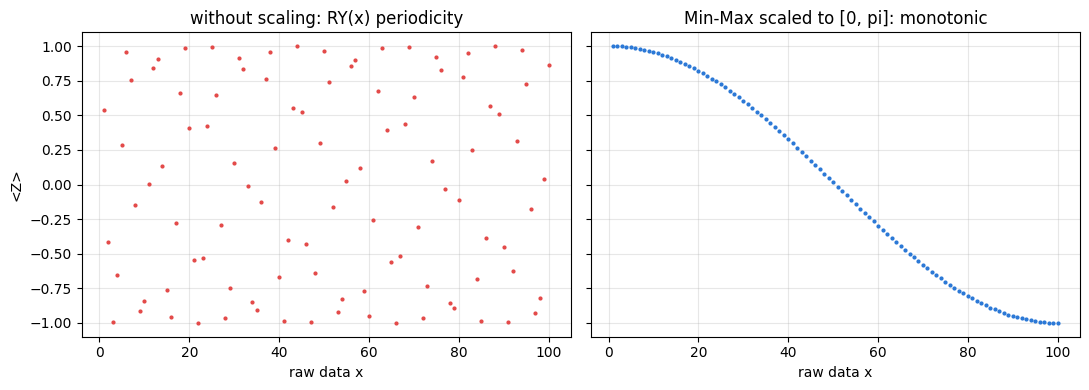

In [7]:

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
a.plot(x_int, raw, ".", color="#e34948", ms=4)
a.set_title("without scaling: RY(x) periodicity")
a.set_xlabel("raw data x"); a.set_ylabel("<Z>"); a.grid(alpha=0.3)
b.plot(x_int, scaled, ".", color="#2a78d6", ms=4)
b.set_title("Min-Max scaled to [0, pi]: monotonic")
b.set_xlabel("raw data x"); b.grid(alpha=0.3)
b.set_ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()



In [8]:

# %%
# ===========================================================
#  5-3: 데이터 벡터를 여러 큐빗에 인코딩
# ===========================================================
print("\n" + "=" * 60)
print("lab5-3: 데이터 벡터 -> 3큐빗")
print("=" * 60)

data = np.array([0.5, 0.75, 0.3])       # 특징 3개 (이미 [-1,1] 범위)
angles = np.arccos(data)
dev3 = qml.device("default.qubit", wires=3)


@qml.qnode(dev3)
def encode_vec(angs):
    for i in range(len(angs)):
        qml.RY(angs[i], wires=i)         # 큐빗 i 에 특징 i 를 실음
    return [qml.expval(qml.PauliZ(i)) for i in range(len(angs))]




lab5-3: 데이터 벡터 -> 3큐빗



[인코딩 회로]
0: ──RY(1.05)─┤  <Z>
1: ──RY(0.72)─┤  <Z>
2: ──RY(1.27)─┤  <Z>


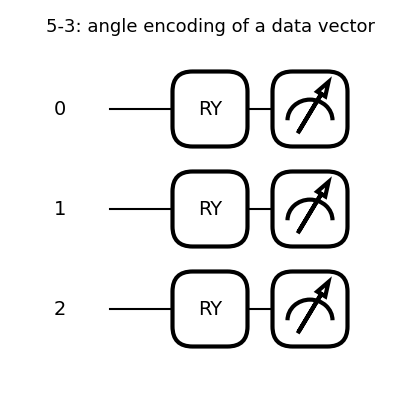


원본 데이터 : [0.5, 0.75, 0.3]
되읽은 <Z_i>: [0.5, 0.75, 0.3]
=> 각 큐빗의 <Z> 가 원래 특징값과 일치. 데이터가 상태에 안전히 담겼다.


In [9]:

print("\n[인코딩 회로]")
print(qml.draw(encode_vec)(angles))
fig, ax = qml.draw_mpl(encode_vec, style="black_white")(angles)
fig.suptitle("5-3: angle encoding of a data vector", fontsize=13)
plt.tight_layout()
plt.show()

recovered = [float(z) for z in encode_vec(angles)]
print("\n원본 데이터 :", [round(float(d), 3) for d in data])
print("되읽은 <Z_i>:", [round(z, 3) for z in recovered])
print("=> 각 큐빗의 <Z> 가 원래 특징값과 일치. 데이터가 상태에 안전히 담겼다.")


In [10]:


# %%
# ===========================================================
#  5-4: 다른 데이터 = 다른 양자 상태 (특징)
# ===========================================================
print("\n" + "=" * 60)
print("lab5-4: 서로 다른 데이터는 서로 다른 상태가 된다")
print("=" * 60)


@qml.qnode(dev3)
def encode_probs(angs):
    for i in range(len(angs)):
        qml.RY(angs[i], wires=i)
    return [qml.probs(wires=i) for i in range(len(angs))]


samples = {
    "A [0.5, 0.75, 0.3]": np.array([0.5, 0.75, 0.3]),
    "B [-0.4, 0.2, 0.9]": np.array([-0.4, 0.2, 0.9]),
    "C [0.9, -0.6, 0.0]": np.array([0.9, -0.6, 0.0]),
}



lab5-4: 서로 다른 데이터는 서로 다른 상태가 된다


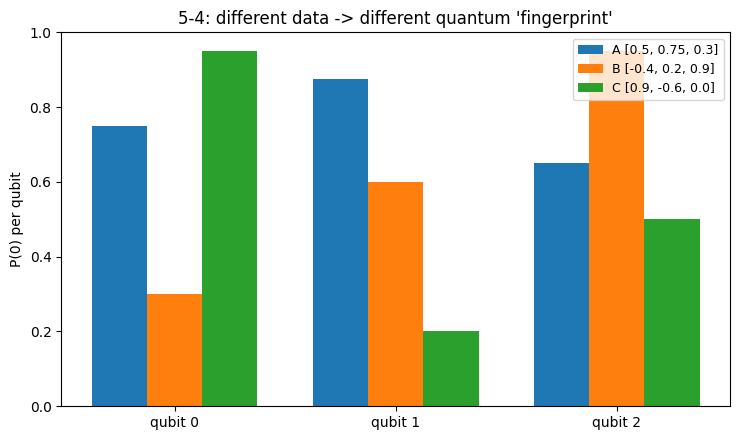


=> 데이터마다 큐빗별 P(0) 패턴('지문')이 다르다. 이 차이가 분류의 근거가 된다.


In [11]:

fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = std_np.arange(3)
w = 0.25
for k, (name, d) in enumerate(samples.items()):
    pr = encode_probs(np.arccos(d))
    p0 = [float(q[0]) for q in pr]
    ax.bar(x + (k - 1) * w, p0, w, label=name)
ax.set_xticks(x)
ax.set_xticklabels(["qubit 0", "qubit 1", "qubit 2"])
ax.set_ylim(0, 1)
ax.set_ylabel("P(0) per qubit")
ax.set_title("5-4: different data -> different quantum 'fingerprint'")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("\n=> 데이터마다 큐빗별 P(0) 패턴('지문')이 다르다. 이 차이가 분류의 근거가 된다.")




lab5-5: 특징 사상(feature map)과 양자 커널로 가는 다리

[얽힘을 더한 특징 사상 회로]
0: ──RY(1.05)─╭●────┤  State
1: ──RY(0.72)─╰X─╭●─┤  State
2: ──RY(1.27)────╰X─┤  State


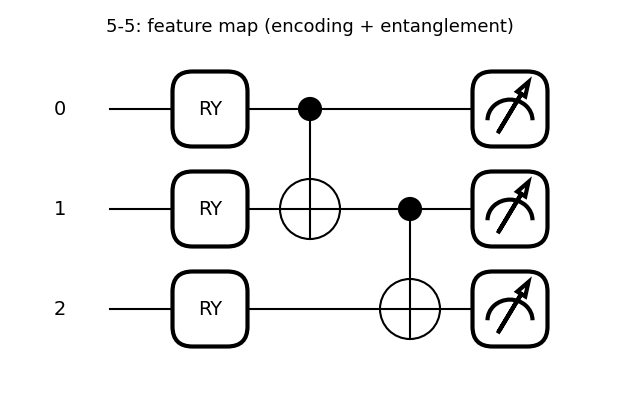


핵심: 인코딩 뒤 얽힘을 넣으면 특징들이 섞여 고전적으로 흉내 내기 어려운
      복잡한 상태(특징 사상)가 된다. 두 데이터의 이런 상태가 얼마나 겹치는지가
      바로 '양자 커널' 이며, 양자 커널 SVM 분류의 핵심 재료가 된다.


In [12]:

# %%
# ===========================================================
#  5-5: (다리) 얽힘을 더하면 '특징 사상' — 양자 커널로
# ===========================================================
print("\n" + "=" * 60)
print("lab5-5: 특징 사상(feature map)과 양자 커널로 가는 다리")
print("=" * 60)


@qml.qnode(dev3)
def feature_map(angs):
    for i in range(len(angs)):          # 1) 데이터 인코딩
        qml.RY(angs[i], wires=i)
    qml.CNOT([0, 1]); qml.CNOT([1, 2])  # 2) 얽힘 -> 특징들이 상호작용
    return qml.state()


print("\n[얽힘을 더한 특징 사상 회로]")
print(qml.draw(feature_map)(angles))
fig, ax = qml.draw_mpl(feature_map, style="black_white")(angles)
fig.suptitle("5-5: feature map (encoding + entanglement)", fontsize=13)
plt.tight_layout()
plt.show()

print("\n핵심: 인코딩 뒤 얽힘을 넣으면 특징들이 섞여 고전적으로 흉내 내기 어려운")
print("      복잡한 상태(특징 사상)가 된다. 두 데이터의 이런 상태가 얼마나 겹치는지가")
print("      바로 '양자 커널' 이며, 양자 커널 SVM 분류의 핵심 재료가 된다.")